# Installation
Full installation instructions can be found [here](https://github.com/dafyddstephenson/C-Star/tree/python_package/cstar_ocean/README.md) (`README.md` in the parent directory)


In [1]:
import os
import cstar

# Introduction to C-Star "v0" with the `roms_marbl_example` Case

In this notebook we will review the `roms_marbl_example` C-Star simulation. We can instantiate a C-Star simulation either from a blueprint (`.yaml` file) or by manually setting it up. Here, we'll build a C-Star simulation from scratch to demonstrate the various structures in C-Star. We will also export the Simulation as a blueprint to be shared or re-used.


## Overview of C-Star structures
- A `Simulation` (`cstar.Simulation`) is the primary object of C-Star. It contains all the necessary information for a user to run a reproducable Earth system simulation. A `Simulation` is composed of external codebase components (`cstar.base.ExternalCodeBase`), each representing a specific configuration of a model of one part of the overall system being simulated. In this notebook we'll be working with an ocean circulation component and a biogeochemistry component.
    - **The `Component` object** itself consists of, at least, a base model (`cstar.base.BaseModel`), and optionally additional code (`cstar.base.AdditionalCode`), input datasets (`cstar.base.InputDataset`), and discretization information (`cstar.base.Discretization`) needed to run the base model in the specific configuration in question. 
        - **A `BaseModel` object** describes the "off-the-shelf" model underlying a Component. It does not contain any information relative to the specific domain, forcing, code modifications, or combination of parameters with which the model will be run in our particular use case. Typically it will simply point (using the `source_repo` attribute) to the repository in which a development team hosts a model (in this case the ROMS and MARBL source code repositories), and features a `checkout_target` attribute instructing C-Star on which version of this source code to use.
        - **An `AdditionalCode` object** also describes code associated with the base model, this time containing code that is necessary to run the base model _in a particular configuration_ of interest. This may include runtime namelist files specifying parameter values and paths to input data, or compile-time option files or source-code modifications. This is effectively code that would not normally be included with a model, but may be required in order to run it. 
        - **An `InputDataset` object** is a descriptor of any non-plaintext file needed to run our base model in a particular configuration. These are typically netCDF files describing the domain, initial conditions, surface and boundary forcing of a particular simulation we'd like to run using the base model.
        - **A `Discretization` object** contains any information related to the discretization of a Component, such as time step and CPU distribution.

- You can find more information on C-Star `Simulation`, `ExternalCodeBase`, `AdditionalCode`, and `InputDataset` objects by querying, e.g., `cstar.Simulation` in a cell.

## The structure of the Simulation:
The `roms_marbl_example` simulation structure breaks down like this:  
```
Simulation
├── ROMSExternalCodeBase
│   └── base_model (ROMSExternalCodeBase)
└── ROMSExternalCodeBase
    ├── base_model (ROMSExternalCodeBase)
    ├── namelists (AdditionalCode)
    ├── additional_source_code (AdditionalCode)
    ├── model_grid (ROMSInputDataset)
    ├── initial_conditions (ROMSInputDataset)
    ├── tidal_forcing (ROMSInputDataset)
    ├── surface_forcing (list of ROMSInputDatasets)
    ├── boundary_forcing (list of ROMSInputDatasets)
    └── discretization (ROMSDiscretization)

```
You will notice that the `Simulation`, `BaseModel`, `InputDataset`, and `Discretization` objects here are specific to the object they describe (e.g. `ROMSBaseModel`). This is because there may be some unique attributes or operations associated with the `BaseModel` object describing ROMS that may be different to that describing MARBL, which has its own subclass `MARBLBaseModel`.

To build this case from the bottom up, we'll need to first build `ExternalCodebase` objects for ROMS and MARBL

## Constructing the ExternalCodebase objects
To initialize an `ExternalCodeBase` object (see `from cstar.base.external_codebase.ExternalCodeBase`), we need a `source_repo` (repository URL containing the base model source code) and a `checkout_target` (a point in the repository history we'd like to jump to). For ROMS we'll use the latest commit hash. For MARBL we'll use `v0.45`, around which the ROMS-MARBL driver was built:

In [2]:
from cstar.roms import ROMSExternalCodeBase
from cstar.marbl import MARBLExternalCodeBase

In [3]:
roms_codebase = ROMSExternalCodeBase(
    source_repo="https://github.com/CESR-lab/ucla-roms.git",
    checkout_target="246c11fa537145ba5868f2256dfb4964aeb09a25",
)

marbl_codebase = MARBLExternalCodeBase(
    source_repo="https://github.com/marbl-ecosys/MARBL.git",
    checkout_target="marbl0.45.0",
)

In [4]:
print(roms_codebase)

Retrieving remote refs for repository `https://github.com/CESR-lab/ucla-roms.git`.
Retrieved remote refs for repository `https://github.com/CESR-lab/ucla-roms.git`.
ROMSExternalCodeBase
--------------------
source_repo : https://github.com/CESR-lab/ucla-roms.git (default)
checkout_target : 246c11fa537145ba5868f2256dfb4964aeb09a25
local_config_status: 3 (Environment variable ROMS_ROOT is not present and it is assumed the external codebase is not installed locally)


/Users/chris/code/cstar/cstar/base/gitutils.py:111: UserWarning: C-STAR: The checkout target 246c11fa537145ba5868f2256dfb4964aeb09a25 appears to be a commit hash, but it is not possible to verify that this hash is a valid checkout target of https://github.com/CESR-lab/ucla-roms.git
  warnings.warn(


In [5]:
print(marbl_codebase)

Retrieving remote refs for repository `https://github.com/marbl-ecosys/MARBL.git`.
Retrieved remote refs for repository `https://github.com/marbl-ecosys/MARBL.git`.
Retrieving remote refs for repository `https://github.com/marbl-ecosys/MARBL.git`.
Retrieved remote refs for repository `https://github.com/marbl-ecosys/MARBL.git`.
MARBLExternalCodeBase
---------------------
source_repo : https://github.com/marbl-ecosys/MARBL.git (default)
checkout_target : marbl0.45.0 (corresponding to hash 6e6b2f7c32ac5427e6cf46de4222973b8bcaa3d9) (default)
local_config_status: 3 (Environment variable MARBL_ROOT is not present and it is assumed the external codebase is not installed locally)


## Constructing the AdditionalCode objects

To construct an `AdditionalCode` object, we need a `location` pointing to a local or remote directory or repository.
In this example, we will use a remote repository, so we also supply a `subdir` (relative to the repository top level) and `checkout_target` argument to initialise the `AdditionalCode` instance.
We also need to provide a list of files identifying our `AdditionalCode`.

In this example we are using [MARBL](https://github.com/marbl-ecosys/MARBL) and [ROMS](https://github.com/marbl-ecosys/MARBL). As ROMS handles all input and output to MARBL, we only need `AdditionalCode` instances for ROMS: one for run-time files (namelists) and the other for compile-time files (such as ROMS' `.opt` files, which are used to set model parameters).

In [6]:
from cstar.base import AdditionalCode

In [7]:
roms_runtime_code = AdditionalCode(
    location="https://github.com/CWorthy-ocean/cstar_blueprint_roms_marbl_example.git",
    subdir="additional_code/ROMS/namelists",
    checkout_target="a9762a46a36c09225423305a1aaa59bdeb984074",
    files=[
        "roms.in_TEMPLATE",
        "marbl_in",
        "marbl_tracer_output_list",
        "marbl_diagnostic_output_list",
    ],
)
print(roms_runtime_code)

AdditionalCode
--------------
Location: https://github.com/CWorthy-ocean/cstar_blueprint_roms_marbl_example.git
Subdirectory: additional_code/ROMS/namelists
Checkout target: a9762a46a36c09225423305a1aaa59bdeb984074
Working path: None
Exists locally: False (get with AdditionalCode.get())
Files:
    roms.in_TEMPLATE      (roms.in will be used by C-Star based on this template)
    marbl_in
    marbl_tracer_output_list
    marbl_diagnostic_output_list


In [8]:
roms_compile_time_code = AdditionalCode(
    location="https://github.com/CWorthy-ocean/cstar_blueprint_roms_marbl_example.git",
    subdir="additional_code/ROMS/source_mods",
    checkout_target="a9762a46a36c09225423305a1aaa59bdeb984074",
    files=[
        "bgc.opt",
        "bulk_frc.opt",
        "cppdefs.opt",
        "diagnostics.opt",
        "ocean_vars.opt",
        "param.opt",
        "tracers.opt",
        "Makefile",
        "Make.depend",
    ],
)

print(roms_compile_time_code)

AdditionalCode
--------------
Location: https://github.com/CWorthy-ocean/cstar_blueprint_roms_marbl_example.git
Subdirectory: additional_code/ROMS/source_mods
Checkout target: a9762a46a36c09225423305a1aaa59bdeb984074
Working path: None
Exists locally: False (get with AdditionalCode.get())
Files:
    bgc.opt
    bulk_frc.opt
    cppdefs.opt
    diagnostics.opt
    ocean_vars.opt
    param.opt
    tracers.opt
    Makefile
    Make.depend


---
Note that the first entry under `files` for the runtime code is a _template_. C-Star recognises the `_TEMPLATE` suffix and works with a local copy (in this case `roms.in`) that it will modify and use to run ROMS with user choices such as run length.

## Constructing the InputDataset objects
To run this simulation, we need different types of input dataset, each with a specialized subclass of the `InputDataset` class:
- a grid file supplying information about the domain to ROMS (`ROMSModelGrid`)
- An initial condition file from which to start the run (`ROMSInitialConditions`)
- boundary forcing files providing information at the edge of the domain (`ROMSBoundaryConditions`)
- surface forcing files providing information at the upper boundary (`ROMSSurfaceForcing`)
- tidal forcing files providing information on tidal constituents (`ROMSTidalForcing`)

To construct an `InputDataset` object, we need (see `cstar.InputDataset?`):
- a `location` : either a path or URL, pointing to this file.
- a `file_hash` : as our location is a URL in this example, we also need a [SHA256 checksum](https://en.wikipedia.org/wiki/Checksum) to verify any downloads

In our case, all the files associated with our `roms_marbl_example` simulation are small and [fit in a repository](https://github.com/CWorthy-ocean/input_datasets_roms_marbl_example). 

In [9]:
from cstar.roms import (
    ROMSModelGrid,
    ROMSInitialConditions,
    ROMSTidalForcing,
    ROMSBoundaryForcing,
    ROMSSurfaceForcing,
)

In [10]:
# Grid
roms_model_grid = ROMSModelGrid(
    location="https://github.com/CWorthy-ocean/input_datasets_roms_marbl_example/raw/main/roms_grd.nc",
    file_hash="fd537ef8159fabb18e38495ec8d44e2fa1b7fb615fcb1417dd4c0e1bb5f4e41d",
)

# Initial conditions
roms_initial_conditions = ROMSInitialConditions(
    location="https://github.com/CWorthy-ocean/input_datasets_roms_marbl_example/raw/main/MARBL_rst.20120103120000.nc",
    file_hash="fc3bbd039256edc89c898efda0eebc5c53773995598d59310bc6d57f454a6ddd",
)

# Tides
roms_tidal_forcing = ROMSTidalForcing(
    location="https://github.com/CWorthy-ocean/input_datasets_roms_marbl_example/raw/main/roms_tides.nc",
    file_hash="90db174ab174909f9bf27c13fa19995c03f680bcb80e7d012268505b48590338",
)

# Boundary
roms_phys_boundary_forcing = ROMSBoundaryForcing(
    location="https://github.com/CWorthy-ocean/input_datasets_roms_marbl_example/raw/main/roms_bry_2012.nc",
    file_hash="c3b0e14aae6dd5a0d54703fa04cf95960c1970e732c0a230427bf8b0fbbd8bf1",
)
roms_bgc_boundary_forcing = ROMSBoundaryForcing(
    location="https://github.com/CWorthy-ocean/input_datasets_roms_marbl_example/raw/main/roms_bry_bgc_MARBL.nc",
    file_hash="897a8df8ed45841a98b3906f2dd07750decc5c2b50095ba648a855c869c7d3ee",
)

# Surface
roms_bgc_surface_forcing = ROMSSurfaceForcing(
    location="https://github.com/CWorthy-ocean/input_datasets_roms_marbl_example/raw/main/roms_frc_bgc.nc",
    file_hash="621dd23691d87aa93c5cc582daf6c5f18333ed062ff934777d50b63346c3f84d",
)
roms_phys_surface_forcing = ROMSSurfaceForcing(
    location="https://github.com/CWorthy-ocean/input_datasets_roms_marbl_example/raw/main/roms_frc.201201.nc",
    file_hash="923049a9c2ab9ce77fa4a0211585e6848a12e87bf237e7aa310f693c3ac6abfa",
)

We can inspect each dataset to get pertinent information about its state, e.g.:

In [11]:
print(roms_phys_boundary_forcing)

-------------------
ROMSBoundaryForcing
-------------------
Source location: https://github.com/CWorthy-ocean/input_datasets_roms_marbl_example/raw/main/roms_bry_2012.nc
Source file hash: c3b0e14aae6dd5a0d54703fa04cf95960c1970e732c0a230427bf8b0fbbd8bf1
Working path: None ( does not yet exist. Call InputDataset.get() )


## Constructing the Discretization object
Lastly, we need to tell C-Star how we will be discretizing our components. MARBL piggybacks off the discretization of its host model, so we only need to create a `ROMSDiscretization` object. This contains:
- the time step (`time_step` , in seconds)
- the number of processors following x and y for running in parallel (`n_procs_x`, `n_procs_y`)

In [12]:
from cstar.roms import ROMSDiscretization

roms_discretization = ROMSDiscretization(time_step=360, n_procs_x=3, n_procs_y=3)
print(roms_discretization)

ROMSDiscretization
------------------
time_step: 360s
n_procs_x: 3 (Number of x-direction processors)
n_procs_y: 3 (Number of y-direction processors)


## Putting it all together to construct the Simulation
We now have everything we need to create the `ROMSSimulation`

In [13]:
from cstar.roms import ROMSSimulation

### ROMS
The ROMSSimulation object (see `cstar.ROMSSimulation?`) is a little more involved, not just because there are more objects going into it. We should also supply information about how to distribute the domain among CPUs to achieve parallelization.

This is instantiated using a list of components, a name string, and a local path where the case will be run. Additionally we choose a start date and end date for the run. The values below run the case for one model month, which may take several minutes to run (depending on your machine). **If you'd like to run the case more quickly**, modify `end_date` below:

In [14]:
roms_simulation = ROMSSimulation(
    name="ROMS-MARBL-Example",
    directory=f"{os.getcwd()}/outputs/cstar_example_notebook",
    valid_start_date="20120103 12:00:00",
    valid_end_date="20120131 12:00:00",
    start_date="20120103 12:00:00",
    end_date="20120110 12:00:00",
    runtime_code=roms_runtime_code,
    compile_time_code=roms_compile_time_code,
    discretization=roms_discretization,
    model_grid=roms_model_grid,
    initial_conditions=roms_initial_conditions,
    tidal_forcing=roms_tidal_forcing,
    boundary_forcing=[roms_phys_boundary_forcing, roms_bgc_boundary_forcing],
    surface_forcing=[roms_phys_surface_forcing, roms_bgc_surface_forcing],
)
print(roms_simulation)

ROMSSimulation
--------------
Name: ROMS-MARBL-Example
Directory: /Users/chris/code/cstar/examples/outputs/cstar_example_notebook
Start date: 2012-01-03 12:00:00
End date: 2012-01-10 12:00:00
Valid start date: 2012-01-03 12:00:00
Valid end date: 2012-01-31 12:00:00

Discretization: ROMSDiscretization(time_step = 360, n_procs_x = 3, n_procs_y = 3)

Code:
Codebase: ROMSExternalCodeBase instance (query using ROMSSimulation.codebase)
Runtime code: AdditionalCode instance with 4 files (query using ROMSSimulation.runtime_code)
Compile-time code: AdditionalCode instance with 9 files (query using ROMSSimulation.compile_time_code)
MARBL Codebase: MARBLExternalCodeBase instance (query using ROMSSimulation.marbl_codebase)

Input Datasets:
Model grid: <ROMSModelGrid instance>
Initial conditions: <ROMSInitialConditions instance>
Tidal forcing: <ROMSTidalForcing instance>
Surface forcing: <list of 2 ROMSSurfaceForcing instances>
Boundary forcing: <list of 2 ROMSBoundaryForcing instances>
Is setup: F

/Users/chris/code/cstar/cstar/simulation.py:140: UserWarning: Creating ROMSSimulation instance without a specified ExternalCodeBase, default codebase will be used:
Source location: https://github.com/CESR-lab/ucla-roms.git
Checkout target: main

  warnings.warn(
/Users/chris/code/cstar/cstar/roms/simulation.py:236: UserWarning: Creating MARBLSimulation instance without a specified MARBLExternalCodeBase, default codebase will be used:
Source location: https://github.com/marbl-ecosys/MARBL.git
Checkout target: marbl0.45.0

  warnings.warn(


## Visualizing the Simulation:
We can see how the simulation directory will look once the case is set up using `Simulation.tree()`:

In [15]:
print(roms_simulation.tree())

/Users/chris/code/cstar/examples/outputs/cstar_example_notebook
└── ROMS
    ├── input_datasets
    │   ├── roms_grd.nc
    │   ├── MARBL_rst.20120103120000.nc
    │   ├── roms_tides.nc
    │   ├── roms_bry_2012.nc
    │   ├── roms_bry_bgc_MARBL.nc
    │   ├── roms_frc.201201.nc
    │   └── roms_frc_bgc.nc
    ├── runtime_code
    │   ├── roms.in_TEMPLATE
    │   ├── marbl_in
    │   ├── marbl_tracer_output_list
    │   └── marbl_diagnostic_output_list
    └── compile_time_code
        ├── bgc.opt
        ├── bulk_frc.opt
        ├── cppdefs.opt
        ├── diagnostics.opt
        ├── ocean_vars.opt
        ├── param.opt
        ├── tracers.opt
        ├── Makefile
        └── Make.depend



## Prepare the Simulation to run locally
Printing the `roms_simulation` object above outputs `Is setup: False`. The simulation has not yet been set up locally. 

To set the simulation up, we run `roms_simulation.setup()`, which performs a series of actions:
- check the external codebases has been installed and, if not, ask the user if they would like to:
  - download ROMS and compile its dependencies
  - download and compile MARBL
- retrieve any additional code using `AdditionalCode.get()`
- retrieve any input datasets using `InputDataset.get()`

When the external codebases are installed, a file `cstar_local_config.py` will be created (or appended to) defining the user's environment such that these base models are available on your machine next time you import C-Star.

In [16]:
roms_simulation.setup()

2025-04-16 12:29:49,632 | INFO | cstar.roms.simulation.ROMSSimulation::setup:1094: Configuring ROMSSimulation
--------------------------
2025-04-16 12:29:49,636 | INFO | cstar.roms.simulation.ROMSSimulation::setup:1095: Setting up ROMSExternalCodeBase...


#######################################################
C-STAR: ROMS_ROOT not found in current cstar_sysmgr.environment. 
if this is your first time running C-Star with an instance of ROMSExternalCodeBase, you will need to set it up.
It is recommended that you install this external codebase in 
/Users/chris/code/cstar/cstar/externals/ucla-roms
This will also modify your `~/.cstar.env` file.
#######################################################
Cloning `https://github.com/CESR-lab/ucla-roms.git`


2025-04-16 12:29:55,284 | INFO | cstar.base.utils::_update_user_dotenv:42: Updating environment in C-Star configuration file ~/.cstar.env
2025-04-16 12:29:55,284 | INFO | cstar.base.utils::_update_user_dotenv:45: Updating environment in C-Star configuration file /Users/chris/.cstar.env


Cloned https://github.com/CESR-lab/ucla-roms.git to /Users/chris/code/cstar/cstar/externals/ucla-roms
Checking out `https://github.com/CESR-lab/ucla-roms.git` @ `main`
Checked out main in git repository /Users/chris/code/cstar/cstar/externals/ucla-roms
Compiling NHMG library...
Command completed successfully.
Compiling Tools-Roms package for UCLA ROMS...


2025-04-16 12:30:10,172 | INFO | cstar.roms.simulation.ROMSSimulation::setup:1099: Setting up MARBLExternalCodeBase...


...

MARBL successfully installed at /Users/chris/code/cstar/cstar/externals/MARBL
Cloning `https://github.com/CWorthy-ocean/cstar_blueprint_roms_marbl_example.git`


2025-04-16 12:30:26,480 | INFO | cstar.base.additional_code.AdditionalCode::get:209: Copying bgc.opt to /Users/chris/code/cstar/examples/outputs/cstar_example_notebook/ROMS/compile_time_code
2025-04-16 12:30:26,481 | INFO | cstar.base.additional_code.AdditionalCode::get:209: Copying bulk_frc.opt to /Users/chris/code/cstar/examples/outputs/cstar_example_notebook/ROMS/compile_time_code
2025-04-16 12:30:26,481 | INFO | cstar.base.additional_code.AdditionalCode::get:209: Copying cppdefs.opt to /Users/chris/code/cstar/examples/outputs/cstar_example_notebook/ROMS/compile_time_code
2025-04-16 12:30:26,482 | INFO | cstar.base.additional_code.AdditionalCode::get:209: Copying diagnostics.opt to /Users/chris/code/cstar/examples/outputs/cstar_example_notebook/ROMS/compile_time_code
2025-04-16 12:30:26,482 | INFO | cstar.base.additional_code.AdditionalCode::get:209: Copying ocean_vars.opt to /Users/chris/code/cstar/examples/outputs/cstar_example_notebook/ROMS/compile_time_code
2025-04-16 12:30:26,4

Cloned https://github.com/CWorthy-ocean/cstar_blueprint_roms_marbl_example.git to /var/folders/pj/bk3042bs0tldhwq8htgfnm640000gn/T/tmppdberw1u
Checking out `https://github.com/CWorthy-ocean/cstar_blueprint_roms_marbl_example.git` @ `a9762a46a36c09225423305a1aaa59bdeb984074`
Checked out a9762a46a36c09225423305a1aaa59bdeb984074 in git repository /var/folders/pj/bk3042bs0tldhwq8htgfnm640000gn/T/tmppdberw1u
Cloning `https://github.com/CWorthy-ocean/cstar_blueprint_roms_marbl_example.git`


2025-04-16 12:30:27,718 | INFO | cstar.base.additional_code.AdditionalCode::get:209: Copying roms.in_TEMPLATE to /Users/chris/code/cstar/examples/outputs/cstar_example_notebook/ROMS/runtime_code
2025-04-16 12:30:27,719 | INFO | cstar.base.additional_code.AdditionalCode::get:222: Copying template file /Users/chris/code/cstar/examples/outputs/cstar_example_notebook/ROMS/runtime_code/roms.in_TEMPLATE to editable version /Users/chris/code/cstar/examples/outputs/cstar_example_notebook/ROMS/runtime_code/roms.in
2025-04-16 12:30:27,719 | INFO | cstar.base.additional_code.AdditionalCode::get:209: Copying marbl_in to /Users/chris/code/cstar/examples/outputs/cstar_example_notebook/ROMS/runtime_code
2025-04-16 12:30:27,720 | INFO | cstar.base.additional_code.AdditionalCode::get:209: Copying marbl_tracer_output_list to /Users/chris/code/cstar/examples/outputs/cstar_example_notebook/ROMS/runtime_code
2025-04-16 12:30:27,720 | INFO | cstar.base.additional_code.AdditionalCode::get:209: Copying marbl_

Cloned https://github.com/CWorthy-ocean/cstar_blueprint_roms_marbl_example.git to /var/folders/pj/bk3042bs0tldhwq8htgfnm640000gn/T/tmpjzf3x1yu
Checking out `https://github.com/CWorthy-ocean/cstar_blueprint_roms_marbl_example.git` @ `a9762a46a36c09225423305a1aaa59bdeb984074`
Checked out a9762a46a36c09225423305a1aaa59bdeb984074 in git repository /var/folders/pj/bk3042bs0tldhwq8htgfnm640000gn/T/tmpjzf3x1yu


## Saving the Case to a YAML file
We can save all the information associated with this case to a YAML file using `Simulation.to_blueprint(filename)`
If we want to run this exact Simulation again, we can use the `Simulation.from_blueprint(filename)` method:

In [17]:
blueprint_name = f"{roms_simulation.directory}/roms_simulation_blueprint.yaml"
roms_simulation.to_blueprint(blueprint_name)

In [18]:
with open(blueprint_name, "r") as f:
    blueprint = f.read()

print(blueprint)

name: ROMS-MARBL-Example
valid_start_date: 2012-01-03 12:00:00
valid_end_date: 2012-01-31 12:00:00
codebase:
  source_repo: https://github.com/CESR-lab/ucla-roms.git
  checkout_target: main
discretization:
  time_step: 360
  n_procs_x: 3
  n_procs_y: 3
runtime_code:
  location: https://github.com/CWorthy-ocean/cstar_blueprint_roms_marbl_example.git
  subdir: additional_code/ROMS/namelists
  checkout_target: a9762a46a36c09225423305a1aaa59bdeb984074
  files:
  - roms.in_TEMPLATE
  - marbl_in
  - marbl_tracer_output_list
  - marbl_diagnostic_output_list
compile_time_code:
  location: https://github.com/CWorthy-ocean/cstar_blueprint_roms_marbl_example.git
  subdir: additional_code/ROMS/source_mods
  checkout_target: a9762a46a36c09225423305a1aaa59bdeb984074
  files:
  - bgc.opt
  - bulk_frc.opt
  - cppdefs.opt
  - diagnostics.opt
  - ocean_vars.opt
  - param.opt
  - tracers.opt
  - Makefile
  - Make.depend
marbl_codebase:
  source_repo: https://github.com/marbl-ecosys/MARBL.git
  checkout_t

## Compiling the Simulation 
Now we have all of the necessary code and data to run the simulation, we can compile it using `roms_simulation.build()`

In [19]:
roms_simulation.build()

Compiling UCLA-ROMS configuration...
UCLA-ROMS compiled at /Users/chris/code/cstar/examples/outputs/cstar_example_notebook/ROMS/compile_time_code


## Running the Simulation
There are three stages to this:
- `roms_simulation.pre_run()` performs pre-processing steps such as partitioning input datasets and modifying namelists to set runtime parameters used by the model (such as the time step)
- `roms_simulation.run()` calls the executable that we created with `roms_simulation.build()`
- `roms_simulation.post_run()` performs post-processing steps such as joining output datasets (which are output in tiles, one per processor)

In [20]:
roms_simulation.pre_run()

2025-04-16 12:30:43,871 | INFO | cstar.roms.input_dataset.ROMSModelGrid::partition:108: Partitioning /Users/chris/code/cstar/examples/outputs/cstar_example_notebook/ROMS/input_datasets/roms_grd.nc into (3,3)
2025-04-16 12:30:43,976 | INFO | cstar.roms.input_dataset.ROMSInitialConditions::partition:108: Partitioning /Users/chris/code/cstar/examples/outputs/cstar_example_notebook/ROMS/input_datasets/MARBL_rst.20120103120000.nc into (3,3)
2025-04-16 12:30:44,642 | INFO | cstar.roms.input_dataset.ROMSTidalForcing::partition:108: Partitioning /Users/chris/code/cstar/examples/outputs/cstar_example_notebook/ROMS/input_datasets/roms_tides.nc into (3,3)
2025-04-16 12:30:44,682 | INFO | cstar.roms.input_dataset.ROMSBoundaryForcing::partition:108: Partitioning /Users/chris/code/cstar/examples/outputs/cstar_example_notebook/ROMS/input_datasets/roms_bry_2012.nc into (3,3)
/opt/anaconda3/envs/cstar/lib/python3.13/site-packages/roms_tools/tiling/partition.py:322: FutureWarning: In a future version of

In [21]:
handler = roms_simulation.run()
handler

LocalProcess(
commands = 'mpirun -n 9 /Users/chris/code/cstar/examples/outputs/cstar_example_notebook/ROMS/compile_time_code/roms /Users/chris/code/cstar/examples/outputs/cstar_example_notebook/ROMS/runtime_code/roms.in',
output_file = PosixPath('/Users/chris/code/cstar/examples/outputs/cstar_example_notebook/output/cstar_process_20250416_123045.out'),
run_path = PosixPath('/Users/chris/code/cstar/examples/outputs/cstar_example_notebook/output')
)
State: <status = <ExecutionStatus.RUNNING: 3>>

In [22]:
# Use the handler to request status updates on the simulation
handler.updates(0, confirm_indefinite=True)

if handler.status != cstar.execution.handler.ExecutionStatus.RUNNING:
    print(handler.status)

if handler.status == cstar.execution.handler.ExecutionStatus.FAILED:
    print("An error occurred. See:", handler.output_file)
else:
    roms_simulation.post_run()

2025-04-16 12:30:48,723 | INFO | cstar.execution.local_process.LocalProcess::updates:168:          set_frc :: swrad            input time (days) =   4385.67     rec =  65

2025-04-16 12:30:48,723 | INFO | cstar.execution.local_process.LocalProcess::updates:168:          set_frc :: lwrad            input time (days) =   4385.67     rec =  65

2025-04-16 12:30:48,724 | INFO | cstar.execution.local_process.LocalProcess::updates:168:          set_frc :: uwnd             input time (days) =   4385.67     rec =  65

2025-04-16 12:30:48,724 | INFO | cstar.execution.local_process.LocalProcess::updates:168:          set_frc :: vwnd             input time (days) =   4385.67     rec =  65

2025-04-16 12:30:48,725 | INFO | cstar.execution.local_process.LocalProcess::updates:168:          set_frc :: Tair             input time (days) =   4385.67     rec =  65

2025-04-16 12:30:48,725 | INFO | cstar.execution.local_process.LocalProcess::updates:168:          set_frc :: qair             input time (d

completed
Joining netCDF files ROMS_MARBL_rst.20120108120000.*.nc...
Command completed successfully.
Joining netCDF files ROMS_MARBL_his.20120103120000.*.nc...
Command completed successfully.
Joining netCDF files ROMS_MARBL_his.20120109120000.*.nc...
Command completed successfully.
Joining netCDF files ROMS_MARBL_rst.20120107120000.*.nc...
Command completed successfully.
Joining netCDF files ROMS_MARBL_rst.20120106120000.*.nc...
Command completed successfully.
Joining netCDF files ROMS_MARBL_bgc.20120103120000.*.nc...
Command completed successfully.
Joining netCDF files ROMS_MARBL_rst.20120109120000.*.nc...
Command completed successfully.
Joining netCDF files ROMS_MARBL_his.20120110120000.*.nc...
Command completed successfully.
Joining netCDF files ROMS_MARBL_his.20120106120000.*.nc...
Command completed successfully.
Joining netCDF files ROMS_MARBL_his.20120105120000.*.nc...
Command completed successfully.
Joining netCDF files ROMS_MARBL_rst.20120104120000.*.nc...
Command completed suc

## A quick look at the output
The output of the case consists of 4 file types:
- `ROMS_MARBL_bgc.20120103120000.nc` contains the 32 BGC tracers
- `ROMS_MARBL_bgc_dia.20120103120000.nc` contains 343 BGC diagnostics
- `ROMS_MARBL_his.201201??120000.nc` contains ocean physics variables
- `ROMS_MARBL_rst.201201??120000.nc` are restart files

In [23]:
!ls {roms_simulation.directory}/output/

PARTITIONED                          ROMS_MARBL_his.20120110120000.nc
ROMS_MARBL_bgc.20120103120000.nc     ROMS_MARBL_rst.20120104120000.nc
ROMS_MARBL_bgc_dia.20120103120000.nc ROMS_MARBL_rst.20120105120000.nc
ROMS_MARBL_his.20120103120000.nc     ROMS_MARBL_rst.20120106120000.nc
ROMS_MARBL_his.20120104120000.nc     ROMS_MARBL_rst.20120107120000.nc
ROMS_MARBL_his.20120105120000.nc     ROMS_MARBL_rst.20120108120000.nc
ROMS_MARBL_his.20120106120000.nc     ROMS_MARBL_rst.20120109120000.nc
ROMS_MARBL_his.20120107120000.nc     ROMS_MARBL_rst.20120110120000.nc
ROMS_MARBL_his.20120108120000.nc     cstar_process_20250416_123045.out
ROMS_MARBL_his.20120109120000.nc


In [24]:
import numpy as np
import xarray as xr

In [25]:
BGC_DS = xr.open_dataset(
    f"{roms_simulation.directory}/output/ROMS_MARBL_bgc.20120103120000.nc"
)
var = "DOC"
BGC_DA = BGC_DS[var].isel(s_rho=99)

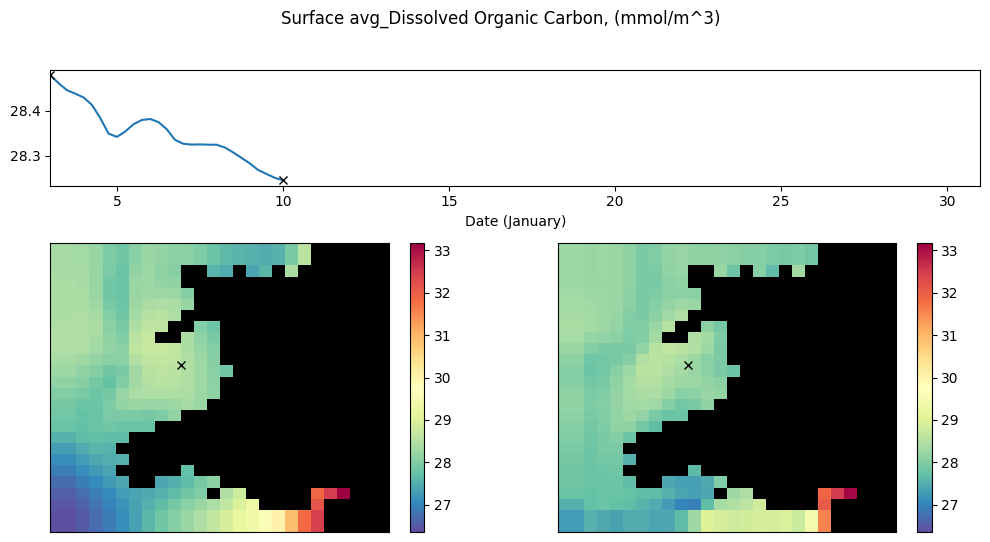

In [26]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fig = plt.figure()
CMAP = plt.colormaps["Spectral_r"].__copy__()
CMAP.set_under("k")

gs = GridSpec(3, 2, figure=fig, hspace=0.5)
ax1 = fig.add_subplot(gs[0, :])

ax2 = fig.add_subplot(gs[1:, 0])
ax3 = fig.add_subplot(gs[1:, 1])

VMIN = np.min(BGC_DA.values[BGC_DA.values > 0])
VMAX = np.max(BGC_DA.values[BGC_DA.values > 0])

p2 = ax2.pcolormesh(BGC_DA.isel(time=0).values, vmin=VMIN, vmax=VMAX, cmap=CMAP)
p3 = ax3.pcolormesh(BGC_DA.isel(time=-1).values, vmin=VMIN, vmax=VMAX, cmap=CMAP)
[a.set_xticks([]) for a in [ax2, ax3]]
[a.set_yticks([]) for a in [ax2, ax3]]
ax2.plot(10, 15, "kx")
ax3.plot(10, 15, "kx")

ax1.plot(3 + BGC_DA.time * 3600 * 6 / 86400, BGC_DA[:, 15, 10])
ax1.set_xlim(3, 31)
ax1.set_xlabel("Date (January)")
# ax1.set_ylim(VMIN, VMAX)
ax1.plot(3 + BGC_DA.time[0] * 3600 * 6 / 86400, BGC_DA[0, 15, 10], "kx")
ax1.plot(3 + BGC_DA.time[-1] * 3600 * 6 / 86400, BGC_DA[-1, 15, 10], "kx")
fig.colorbar(p2, ax=ax2)
fig.colorbar(p3, ax=ax3)

fig.suptitle(f"Surface {BGC_DS[var].long_name}, ({BGC_DS[var].units})")
fig.set_size_inches(12, 6)

The "X" in this plot highlights the point whose time series is plotted in the top panel. The lower left panel represents the first snapshot (January 3rd) and the lower right panel represents the final snapshot (January 31st)

In [ ]:
if 0:
    # clean up outputs when done
    import shutil

    shutil.rmtree(roms_simulation.directory, ignore_errors=True)

: 